# March 18 Paper Candidates

Paper-focused audit notebook for reviewed March 18 candidates on canonical migrated paths.

- Data: `output_migrated_camera_field_20260606/runs/runs_march18_bundle_all/review/review.taxonomy_filled.db`
- Shared helpers: `malca.review.paper_candidates`
- Default buckets: Dipper, LTV, Microlensing (matches CMD figure)

**Note:** `lc_events_*.parquet` products are reconstructed from the review DB (`reconstruction_manifest.json`), not original historical pipeline snapshots.

## Setup

In [1]:
from __future__ import annotations

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-mplconfig")

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from malca.notebook_paths import find_repo_root
from malca.lightcurve_publication import figsize_heatmap_two_col
from malca.review.paper_candidates import (
    DEFAULT_PAPER_BUCKETS,
    EXPORT_DIR,
    PAPER_FEATURE_GROUPS,
    audit_flattened_vs_layers,
    export_paper_tables,
    feature_missingness_by_bucket,
    grouped_numeric_summary,
    load_reviewed_cohort,
    mwu_separability_table,
    paper_feature_columns,
    plot_class_examples,
    resolve_paper_paths,
    zscore_median_profile,
)

REPO_ROOT = find_repo_root()
PATHS = resolve_paper_paths(REPO_ROOT)
for key, value in PATHS.items():
    print(f"{key:20s} = {value}")

repo_root            = /Users/calder/code/malca
march18_run          = /Users/calder/code/malca/output_migrated_camera_field_20260606/runs/runs_march18_bundle_all
review_db            = /Users/calder/code/malca/output_migrated_camera_field_20260606/runs/runs_march18_bundle_all/review/review.taxonomy_filled.db
lightcurve_dir       = /Users/calder/code/malca/output_migrated_camera_field_20260606/runs/runs_march18_bundle_all/bundle_assets/lightcurves
classified_parquet   = /Users/calder/code/malca/output_migrated_camera_field_20260606/runs/runs_march18_bundle_all/results/lc_events_classified.parquet
export_dir           = /Users/calder/code/malca/output/notebooks/march18_paper


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load reviewed cohort

In [2]:
PAPER_BUCKETS = list(DEFAULT_PAPER_BUCKETS)
cohort = load_reviewed_cohort(PATHS["review_db"], buckets=PAPER_BUCKETS)
print(f"Reviewed paper cohort: {len(cohort):,} candidates")
display(cohort["review_bucket"].value_counts().to_frame("n"))
cohort[["candidate_id", "review_bucket", "event_class", "interest_score", "morphology_secondary", "physical_primary"]].head(10)

Reviewed paper cohort: 88 candidates


,n
review_bucket,
LTV,36
Microlensing,32
Dipper,20


,candidate_id,review_bucket,event_class,interest_score,morphology_secondary,physical_primary
0,146029419304,Dipper,dipper,1,None,None
1,180388903123,Dipper,dipper,4,None,None
2,188979054063,Microlensing,microlensing,4,possible_microlensing_event,microlensing
3,249108767924,LTV,ltv,1,None,None
4,25770889321,LTV,ltv,1,None,None
5,292058271348,LTV,ltv,1,None,None
6,326418117943,Microlensing,microlensing,1,possible_microlensing_event,microlensing
7,34360526644,LTV,ltv,3,None,None
8,369367489518,Dipper,dipper,1,None,None
9,472447489028,Microlensing,microlensing,2,possible_microlensing_event,microlensing


## Feature inventory

In [3]:
inventory = pd.DataFrame(
    [{"feature_group": name, "n_columns": len(cols), "example_columns": ", ".join(cols[:4])}
     for name, cols in PAPER_FEATURE_GROUPS.items()]
)
inventory["n_columns_present"] = inventory["feature_group"].map(
    lambda g: sum(col in cohort.columns for col in PAPER_FEATURE_GROUPS[g])
)
display(inventory.sort_values("n_columns", ascending=False))
print(f"Total unique paper feature columns: {len(paper_feature_columns())}")

,feature_group,n_columns,example_columns,n_columns_present
12,LTV Multi-Survey,91,"ltv_ms_feature_status, ltv_ms_feature_version,...",91
20,Nuclear Context,63,"gaia_parallax_snr, gaia_pm_snr, gaia_stellar_v...",63
5,LC Harmonics (folded),49,"stats_harmonics_order, stats_harmonics_period,...",49
11,LTV Long-Term Features,47,"ltv_smooth_p95_p5, ltv_smooth_var, ltv_resid_v...",47
21,Vetting,45,"vetting_likely_known, microlens_match, pm_clus...",45
19,External Coverage,44,"neowise_n_epochs, atlas_n_det_cyan, atlas_n_de...",44
2,LC Variability,36,"stats_variability_reduced_chi2_vs_constant, st...",36
8,LTV,28,"ltv_slope, ltv_slope_quad, ltv_dispersion, ltv...",28
1,LC Photometric Scatter,18,"stats_photometry_std_mag, stats_photometry_wei...",18
3,LC Period Search,16,stats_variability_lomb_scargle_best_period_day...,16


Total unique paper feature columns: 580


## Layer JSON audit

In [4]:
layer_audit = audit_flattened_vs_layers(cohort)
if layer_audit.empty:
    print("No flattened-vs-layer mismatches detected.")
else:
    print(f"Found {len(layer_audit):,} layer/flat mismatches")
    display(layer_audit.groupby(["layer", "issue"]).size().unstack(fill_value=0))
    display(layer_audit.head(30))

Found 773 layer/flat mismatches


issue,flat_missing,json_only
layer,,
derived_stats,509,0
external_stats,88,176


,candidate_id,layer,key,issue,json_value,flat_value
0,146029419304,external_stats,dec_deg,json_only,25.637552,None
1,146029419304,external_stats,gaia_id,flat_missing,2023932149190953600,None
2,146029419304,external_stats,ra_deg,json_only,289.584391,None
3,180388903123,external_stats,dec_deg,json_only,4.971989,None
4,180388903123,external_stats,gaia_id,flat_missing,3130958694096678656,None
5,180388903123,external_stats,ra_deg,json_only,99.11849,None
6,188979054063,external_stats,dec_deg,json_only,22.838601,None
7,188979054063,external_stats,gaia_id,flat_missing,3424491877389527168,None
8,188979054063,external_stats,ra_deg,json_only,90.240983,None
9,249108767924,external_stats,dec_deg,json_only,12.100382,None


## Missingness by bucket

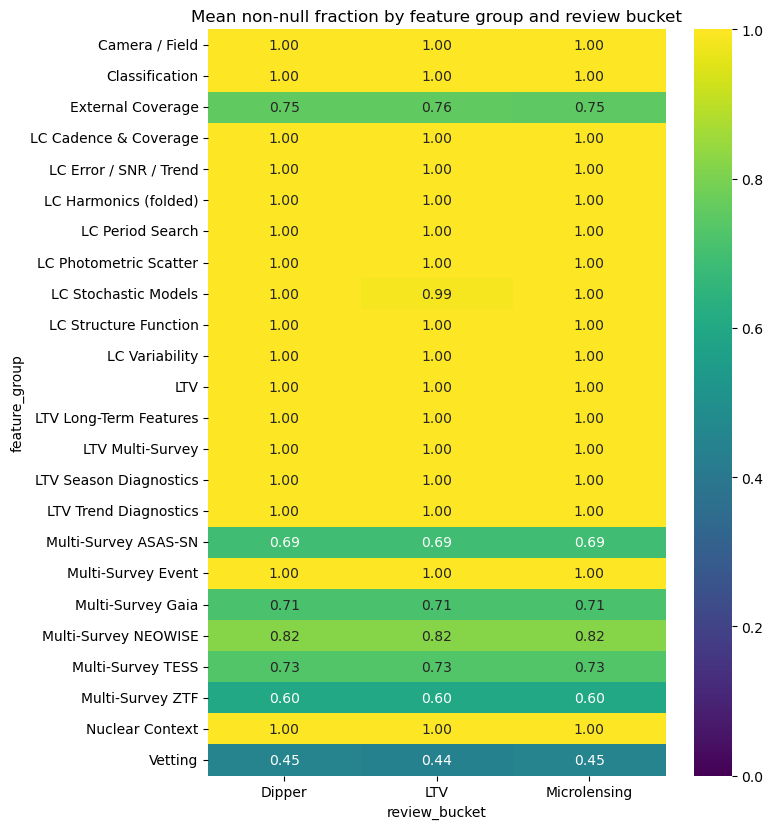

,feature_group,column,review_bucket,n,non_null,non_null_fraction
1716,Camera / Field,asassn_field_key,Dipper,20,20,1.0
1717,Camera / Field,asassn_fields,Dipper,20,20,1.0
1718,Camera / Field,asassn_field_count,Dipper,20,20,1.0
1719,Camera / Field,asassn_field_key_fraction,Dipper,20,20,1.0
1720,Camera / Field,camera_name_key,Dipper,20,20,1.0
1721,Camera / Field,camera_names,Dipper,20,20,1.0
1722,Camera / Field,camera_name_count,Dipper,20,20,1.0
1723,Camera / Field,camera_name_key_fraction,Dipper,20,20,1.0
1724,Camera / Field,asassn_field_key,LTV,36,36,1.0
1725,Camera / Field,asassn_fields,LTV,36,36,1.0


In [5]:
from malca.lightcurve_publication import (
    figsize_heatmap_two_col,
    finalize_publication_figure,
)
missingness = feature_missingness_by_bucket(cohort)
group_missing = (
    missingness.groupby(["feature_group", "review_bucket"])["non_null_fraction"].mean().unstack()
)
plt.figure(figsize=figsize_heatmap_two_col(len(group_missing), row_height=0.35))
sns.heatmap(group_missing, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Mean non-null fraction by feature group and review bucket")
finalize_publication_figure(plt.gcf())
plt.show()
missingness.sort_values(["feature_group", "review_bucket", "non_null_fraction"]).head(40)


## Group-level separability (full feature registry)

review_bucket,Dipper,LTV,Microlensing
feature,,,
camera_name_count,0.000000,0.000000,0.000000
stats_amplitude,0.098265,0.107981,0.047030
stats_anderson_darling,29.764804,11.368649,13.416270
stats_autocor_length,1.000000,1.000000,1.000000
stats_beyond_1_std,0.261542,0.281683,0.245903
stats_clipped_mean_mag_3sigma_about_median,12.846557,12.966203,13.113998
stats_clipped_std_mag_3sigma_about_median,0.035913,0.042063,0.017603
stats_con,24.000000,3.000000,15.500000
stats_constancy_p_value,0.000000,0.000000,0.000000


,feature,reference_group,compare_group,reference_median,compare_median,mwu_pvalue
53,stats_skew,Dipper,Microlensing,1.022927,-0.795457,2.728505e-08
39,stats_gskew,Dipper,Microlensing,0.197462,-0.110043,3.382225e-08
49,stats_percent_amplitude,Dipper,Microlensing,0.015503,0.006539,1.454659e-05
17,stats_variability_stetson_J_time,Dipper,Microlensing,2.339158,0.439029,1.584254e-05
15,stats_variability_stetson_L,Dipper,Microlensing,2.192523,0.648752,1.584254e-05
19,stats_variability_stetson_L_time,Dipper,Microlensing,2.163518,0.396509,1.724809e-05
11,stats_variability_stetson_J,Dipper,Microlensing,2.523427,0.696882,2.042358e-05
5,stats_variability_roms,Dipper,Microlensing,3.397628,1.542202,3.097670e-05
9,stats_variability_stetson_I,Dipper,Microlensing,17.849461,1.690964,3.363372e-05
93,stats_clipped_std_mag_3sigma_about_median,Dipper,Microlensing,0.035913,0.017603,3.363372e-05


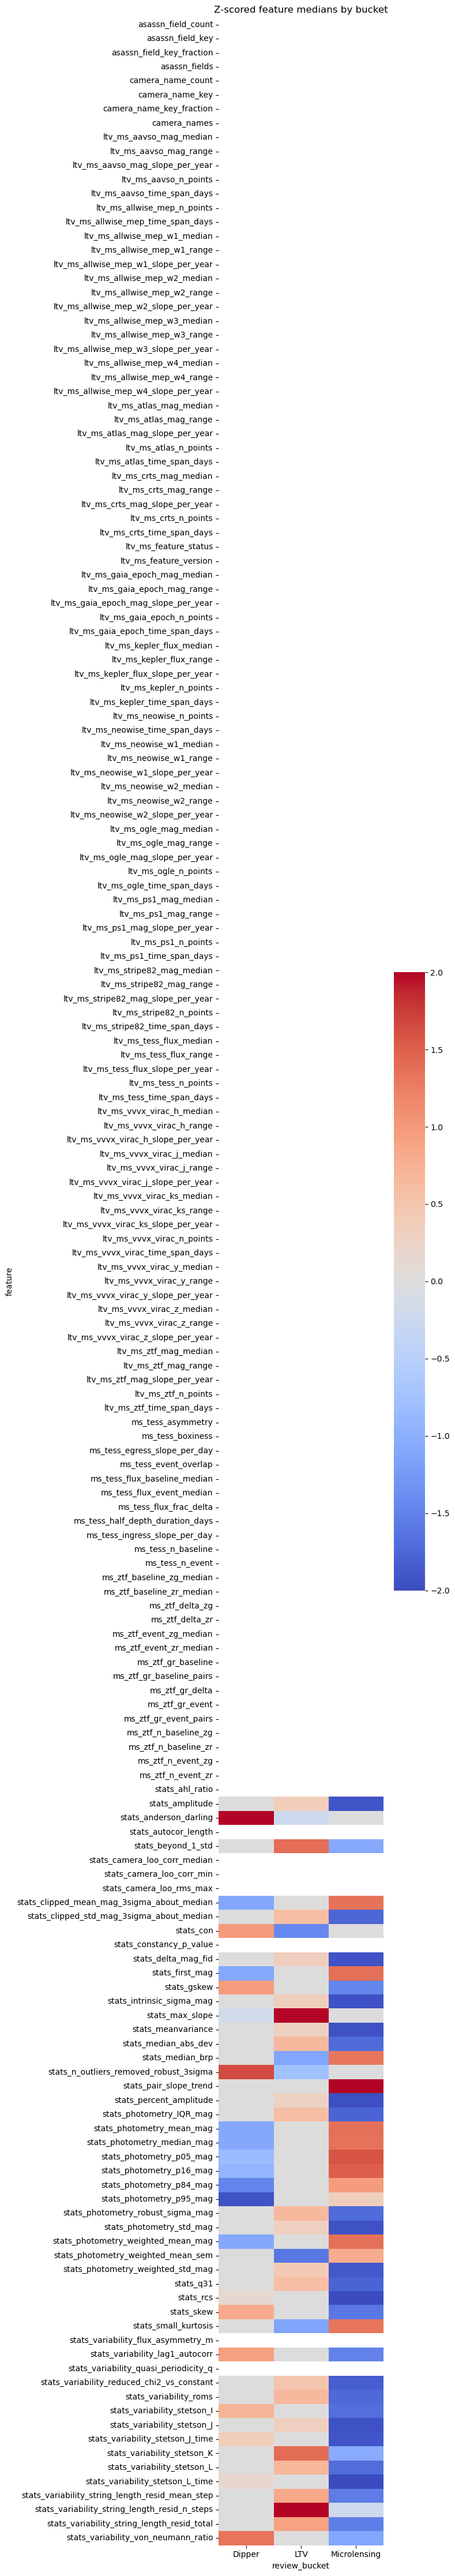

In [6]:
from malca.lightcurve_publication import (
    figsize_heatmap_two_col,
    finalize_publication_figure,
)
stats_features = paper_feature_columns("LC Variability") + paper_feature_columns("LC Photometric Scatter")
ms_features = paper_feature_columns("Multi-Survey ZTF") + paper_feature_columns("Multi-Survey TESS")
ltv_ms_features = paper_feature_columns("LTV Multi-Survey")
camera_features = paper_feature_columns("Camera / Field")

analysis_features = list(dict.fromkeys(stats_features + ms_features + ltv_ms_features + camera_features))
analysis_features = [c for c in analysis_features if c in cohort.columns]

summary_long = grouped_numeric_summary(cohort, analysis_features)
median_profile = summary_long.pivot_table(index="feature", columns="review_bucket", values="median", aggfunc="first")
display(median_profile.iloc[:25])

if len(PAPER_BUCKETS) >= 2:
    mwu = mwu_separability_table(
        cohort,
        analysis_features,
        reference_group=PAPER_BUCKETS[0],
        compare_groups=PAPER_BUCKETS[1:],
    )
    display(mwu.sort_values("mwu_pvalue").head(30))

z_profile = zscore_median_profile(summary_long)
plt.figure(figsize=figsize_heatmap_two_col(len(z_profile), row_height=0.25))
sns.heatmap(z_profile, center=0, cmap="coolwarm", vmin=-2, vmax=2)
plt.title("Z-scored feature medians by bucket")
finalize_publication_figure(plt.gcf())
plt.show()


## Export tables

In [7]:
export_paths = export_paper_tables(cohort, missingness, export_dir=PATHS["export_dir"])
for name, path in export_paths.items():
    print(f"{name}: {path}")

if len(summary_long):
    stats_path = PATHS["export_dir"] / "group_numeric_summary.csv"
    summary_long.to_csv(stats_path, index=False)
    print(f"group_numeric_summary: {stats_path}")

candidate_table: /Users/calder/code/malca/output/notebooks/march18_paper/candidate_table.parquet
feature_missingness: /Users/calder/code/malca/output/notebooks/march18_paper/feature_missingness.csv
feature_group_inventory: /Users/calder/code/malca/output/notebooks/march18_paper/feature_group_inventory.csv
group_numeric_summary: /Users/calder/code/malca/output/notebooks/march18_paper/group_numeric_summary.csv


## Paper figure exports

In [8]:
cmd_out = PATHS["export_dir"] / "march18_review_cmd_ltv_dipper_ml.png"
cmd_script = REPO_ROOT / "scripts" / "plot_march18_review_cmd.py"
subprocess.run(
    [
        sys.executable,
        str(cmd_script),
        "--buckets",
        *PAPER_BUCKETS,
        "--output",
        str(cmd_out),
    ],
    check=True,
    cwd=REPO_ROOT,
)
print(f"CMD plot: {cmd_out}")


Wrote /Users/calder/code/malca/output/notebooks/march18_paper/march18_review_cmd_ltv_dipper_ml.png
Wrote /Users/calder/code/malca/output/notebooks/march18_paper/march18_review_cmd_ltv_dipper_ml.pdf
Wrote /Users/calder/code/malca/output/notebooks/march18_paper/march18_review_cmd_ltv_dipper_ml.csv
all_candidates: 9569
all_cmd_points_solid: 9207
all_cmd_points_hollow: 0
all_cmd_points: 9207
selected_candidates: 88
selected_cmd_points: 83
Dipper_selected: 20
Dipper_plotted: 18
Dipper_plotted_solid: 18
Dipper_plotted_hollow: 0
LTV_selected: 36
LTV_plotted: 33
LTV_plotted_solid: 33
LTV_plotted_hollow: 0
Microlensing_selected: 32
Microlensing_plotted: 32
Microlensing_plotted_solid: 32
Microlensing_plotted_hollow: 0
CMD plot: /Users/calder/code/malca/output/notebooks/march18_paper/march18_review_cmd_ltv_dipper_ml.png


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Plotting examples for Dipper -> /Users/calder/code/malca/output/notebooks/march18_paper/lc_dipper


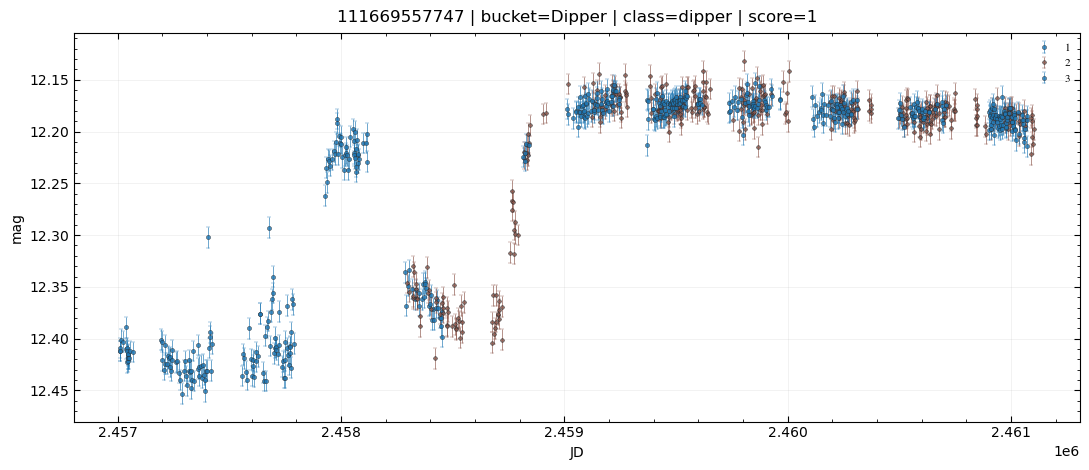

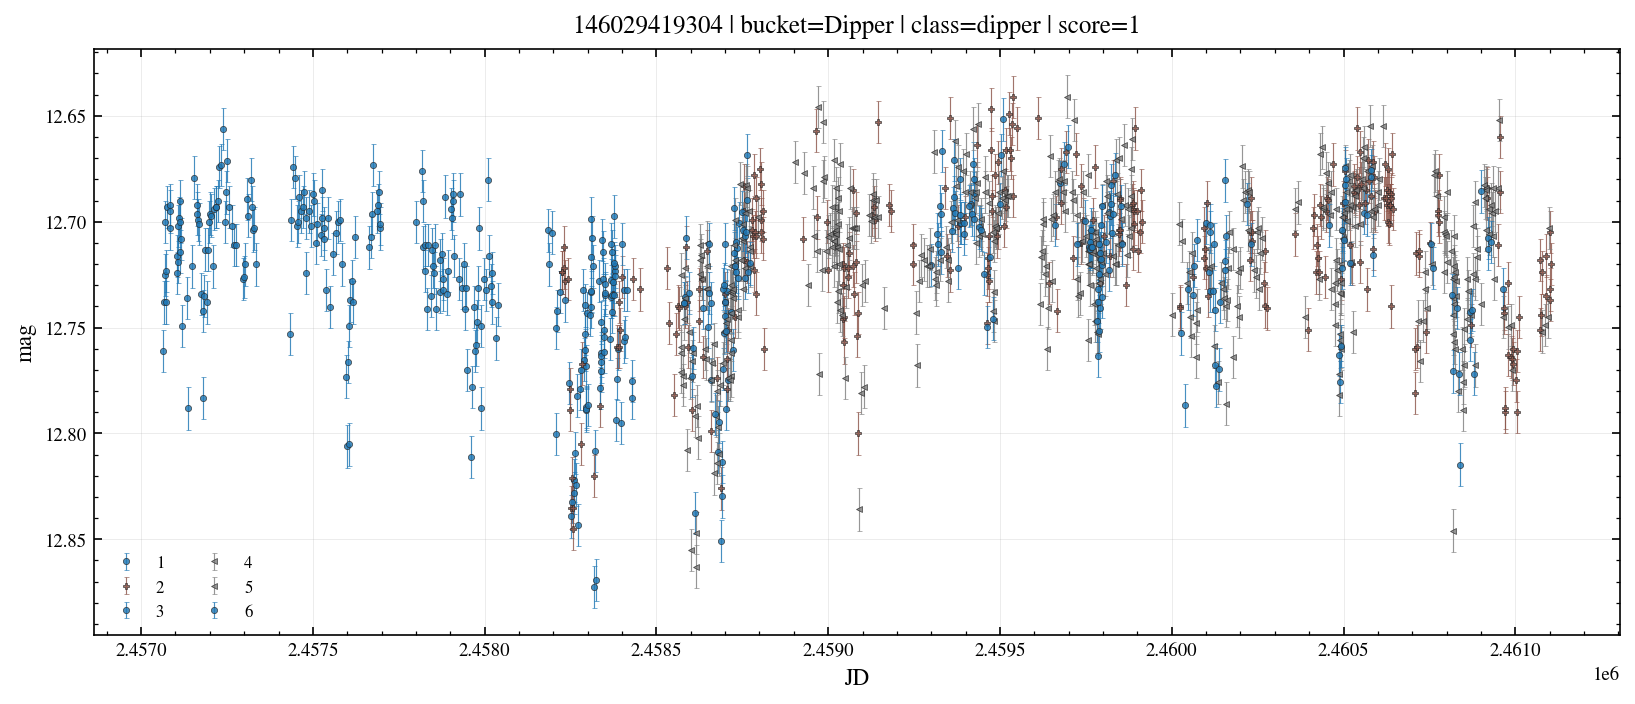

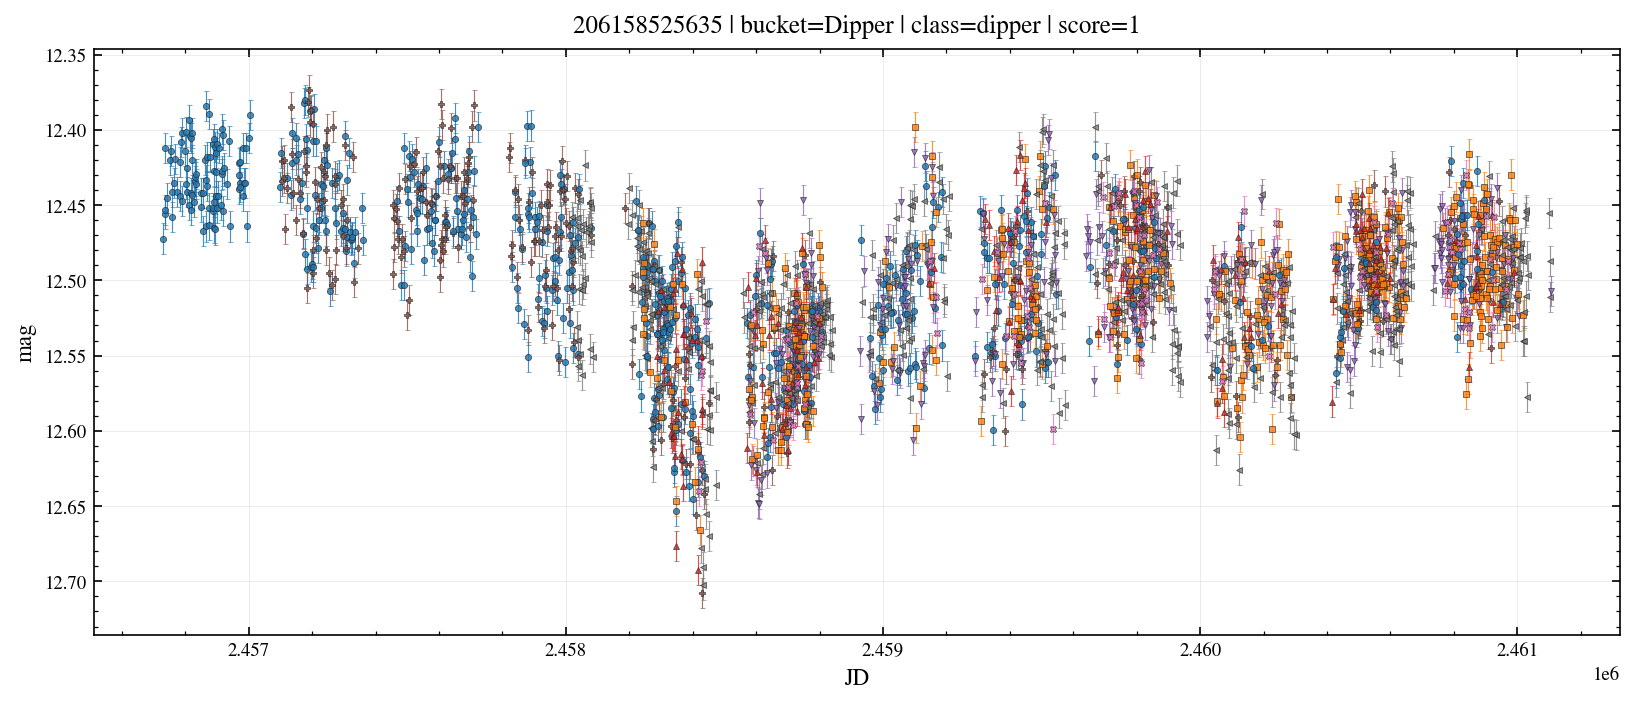

Plotting examples for LTV -> /Users/calder/code/malca/output/notebooks/march18_paper/lc_ltv


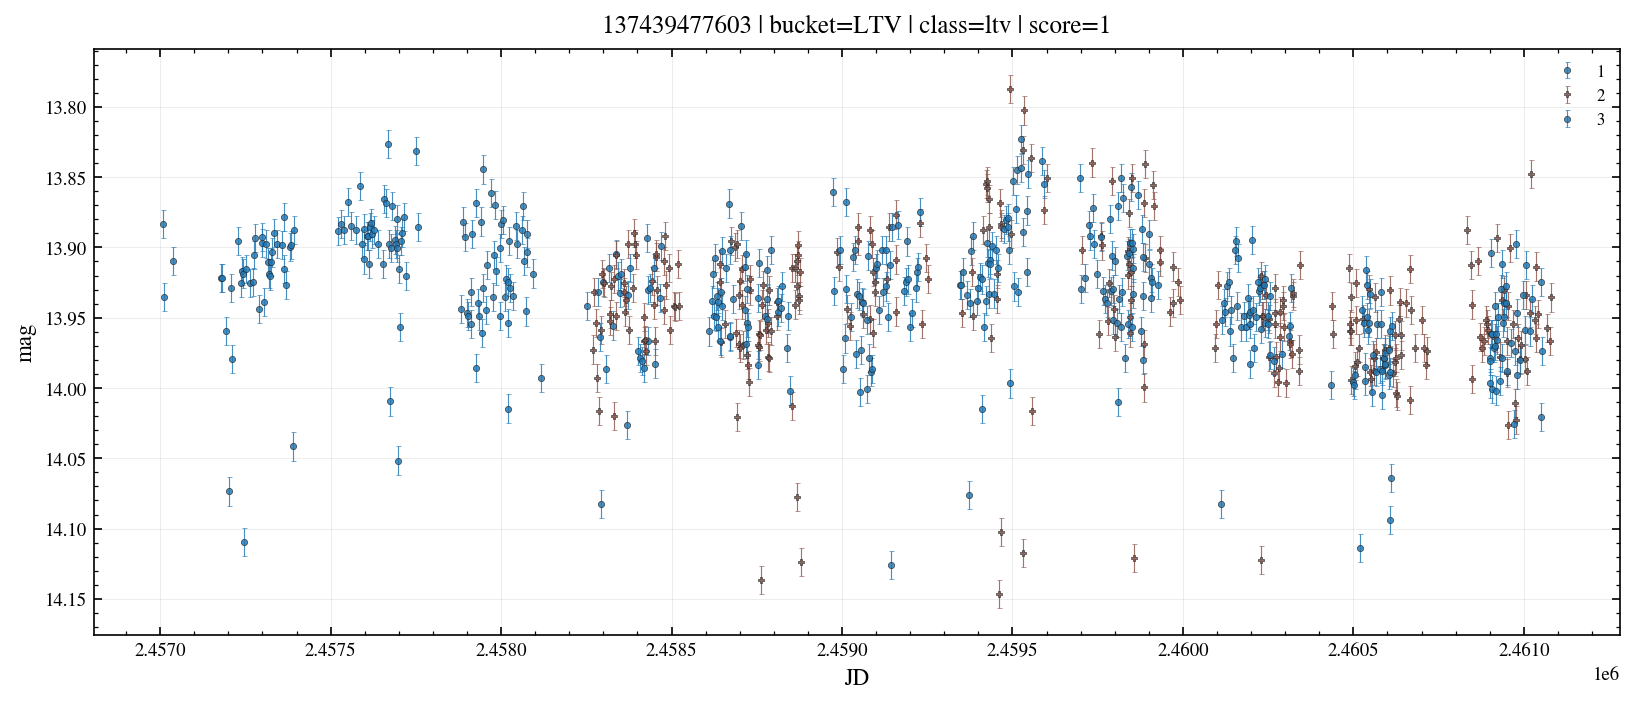

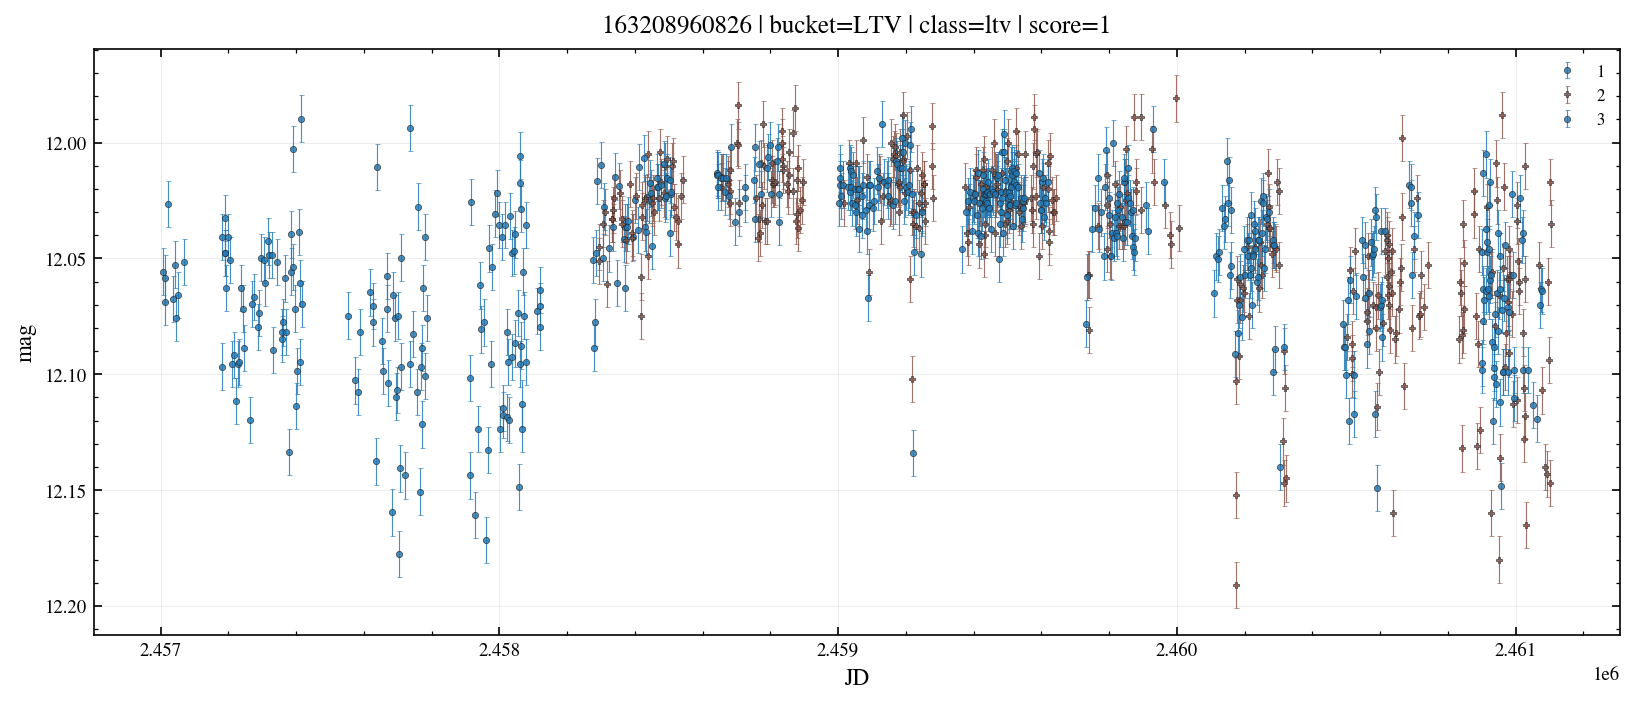

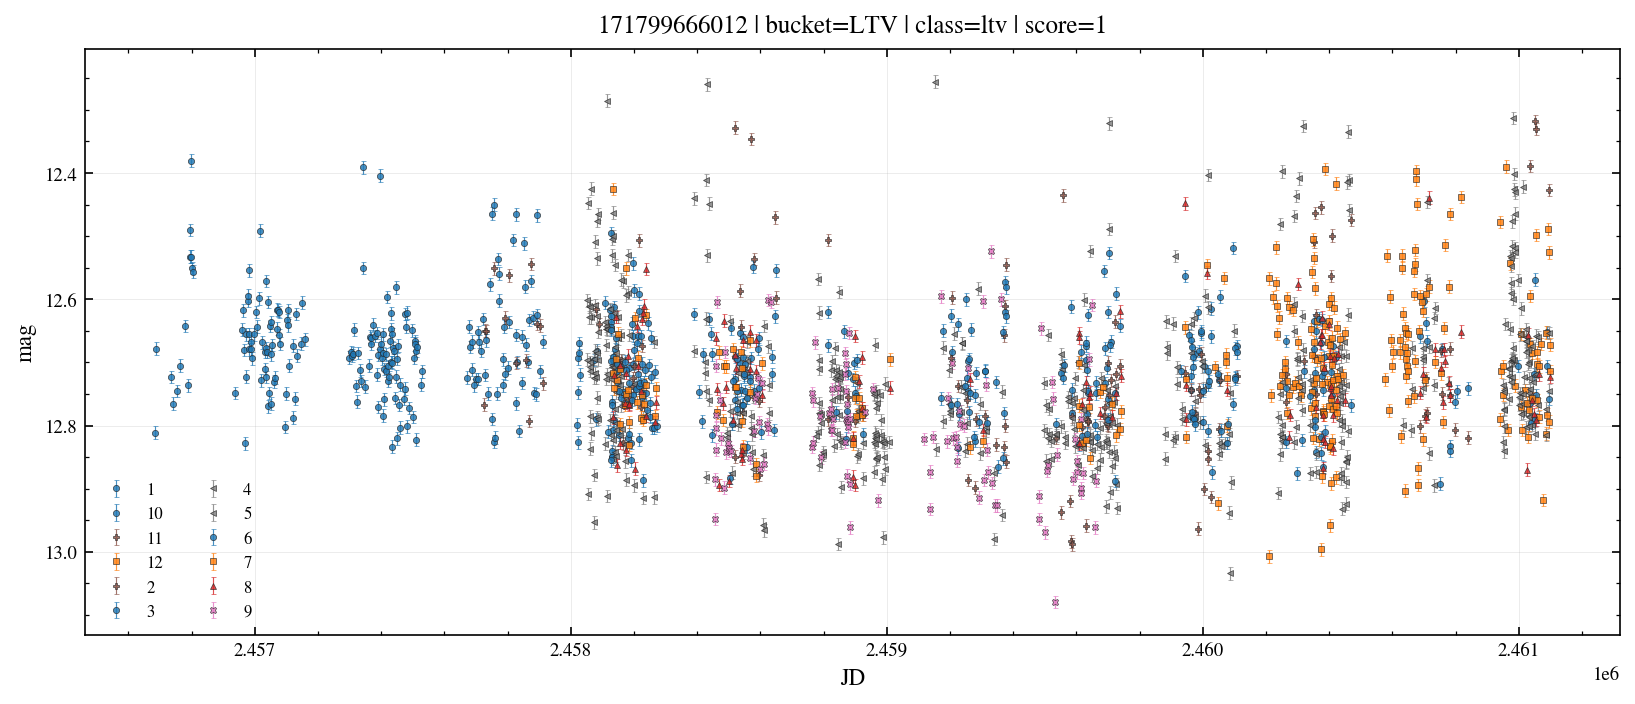

Plotting examples for Microlensing -> /Users/calder/code/malca/output/notebooks/march18_paper/lc_microlensing


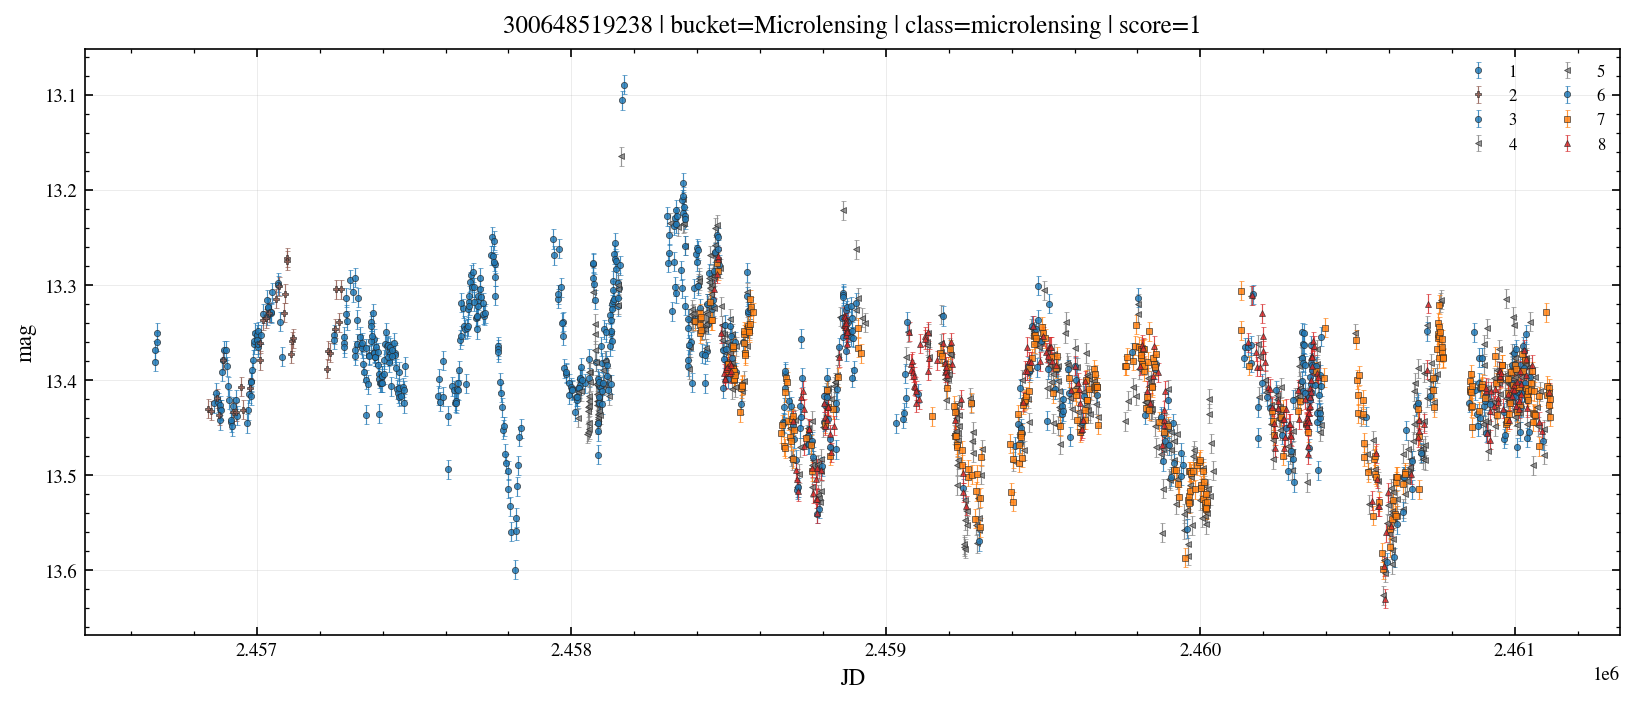

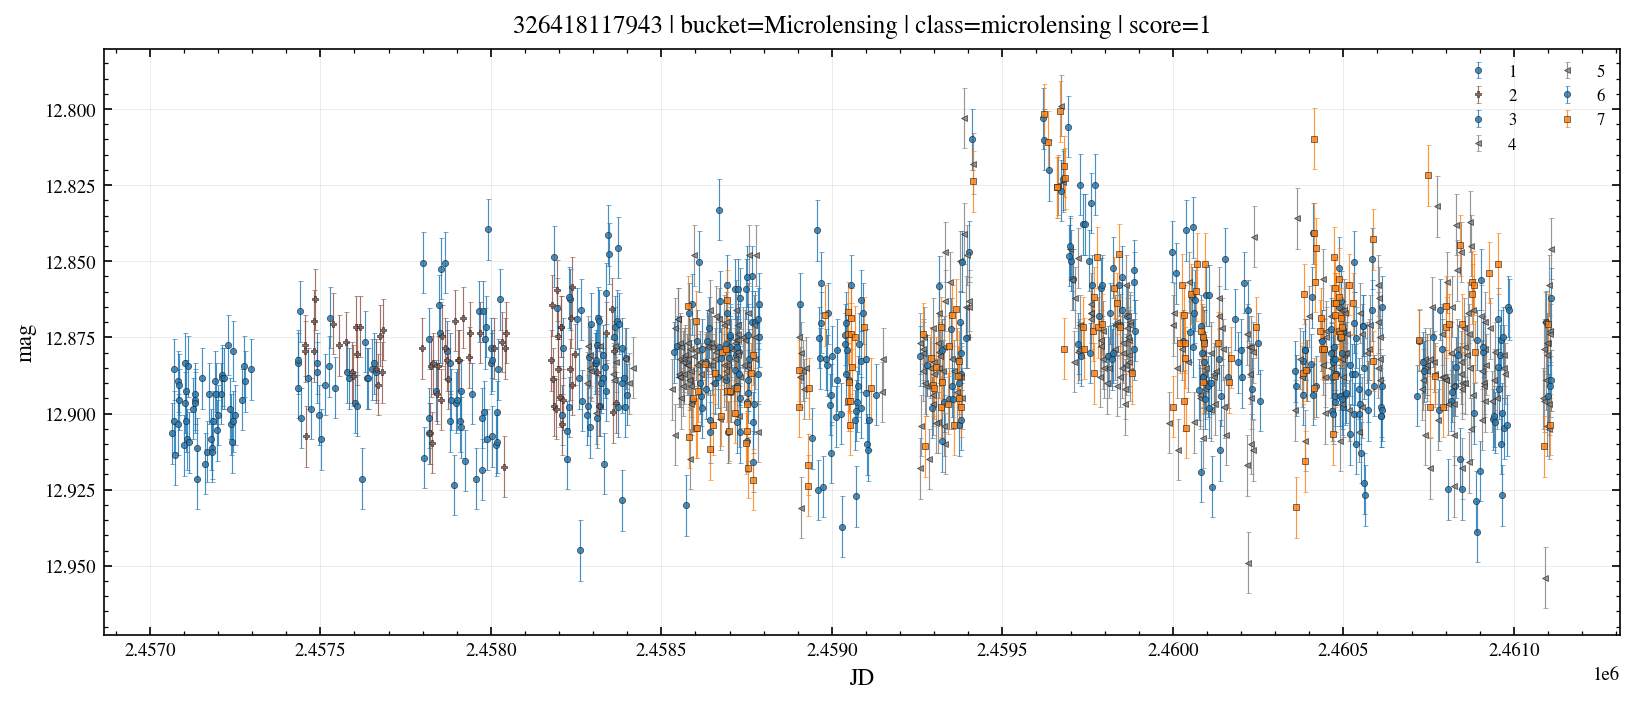

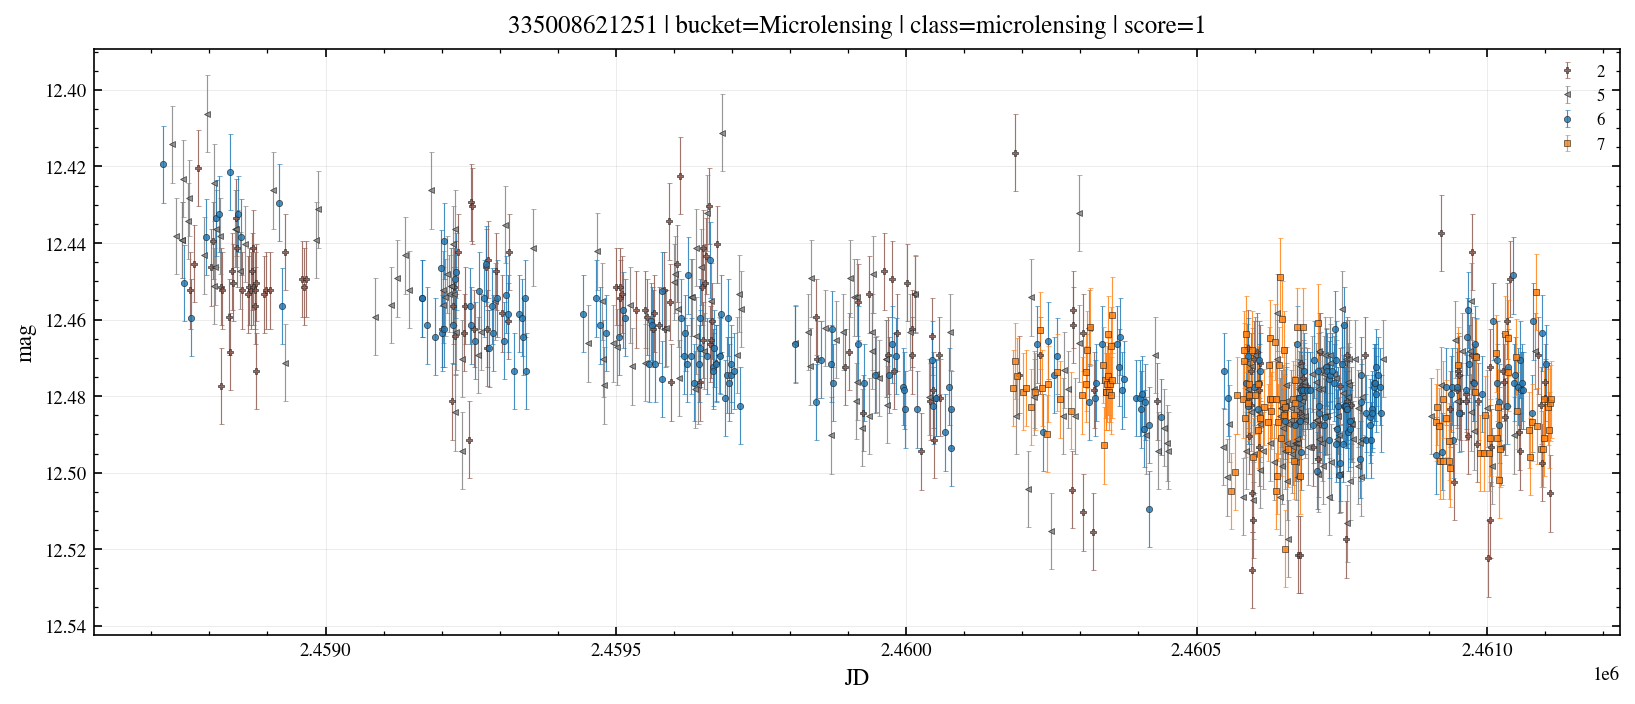

In [9]:
for bucket in PAPER_BUCKETS:
    lc_dir = PATHS["export_dir"] / f"lc_{bucket.lower().replace(' ', '_')}"
    lc_dir.mkdir(parents=True, exist_ok=True)
    print(f"Plotting examples for {bucket} -> {lc_dir}")
    plot_class_examples(cohort, bucket, n=3, run_dir=PATHS["march18_run"])